# 4.1 多层感知机

线性模型只能形成线性决策边界。多层感知机（multilayer perceptron, MLP）在输入层和输出层之间加入一个或多个全连接隐藏层，并用非线性激活函数打破线性限制。

原教材：[4.1 多层感知机](https://zh.d2l.ai/chapter_multilayer-perceptrons/mlp.html)

> 本章代码只使用 PyTorch、Matplotlib 等基础库，不依赖 `d2l`。

## 学习目标

1. 理解为什么连续堆叠线性层仍然只是线性模型；
2. 写出单隐藏层 MLP 的矩阵表达式并判断各张量形状；
3. 掌握 ReLU、sigmoid、tanh 和 pReLU 的定义与梯度特点；
4. 理解激活函数为什么赋予网络拟合非线性关系的能力。

## 4.1.1 隐藏层

设小批量输入 $\mathbf X\in\mathbb R^{n\times d}$，隐藏单元数为 $h$，类别数为 $q$。单隐藏层 MLP 为

$$\mathbf H=\sigma(\mathbf X\mathbf W^{(1)}+\mathbf b^{(1)}),$$

$$\mathbf O=\mathbf H\mathbf W^{(2)}+\mathbf b^{(2)},$$

其中 $\mathbf W^{(1)}\in\mathbb R^{d\times h}$、$\mathbf b^{(1)}\in\mathbb R^h$、$\mathbf W^{(2)}\in\mathbb R^{h\times q}$、$\mathbf b^{(2)}\in\mathbb R^q$。偏置通过广播作用于每个样本。输出 $\mathbf O\in\mathbb R^{n\times q}$ 是 logits。

### 为什么必须有非线性激活

如果去掉 $\sigma$，两层仿射变换可以合并：

$$\mathbf O=(\mathbf X\mathbf W^{(1)}+\mathbf b^{(1)})\mathbf W^{(2)}+\mathbf b^{(2)}=\mathbf X\widetilde{\mathbf W}+\widetilde{\mathbf b}.$$

无论堆叠多少个线性层，整体仍是一个线性层。激活函数使每层不再能被代数合并，网络才有能力形成弯曲或分段的决策边界。

In [3]:
from pathlib import Path  # 统一管理本地与 Google Drive 路径

import matplotlib.pyplot as plt  # 绘图
import torch  # 张量与自动微分

try:  # 尝试判断当前是否运行在 Google Colab 中
    from google.colab import drive  # 仅在 Colab 中可用
    drive.mount('/content/drive')  # 挂载用户的“我的云端硬盘”
    project_root = Path('/content/drive/MyDrive/d2l_learning')  # 指向云盘中的项目根目录
except ImportError:  # 本地环境没有 google.colab 时进入此分支
    # 本地从仓库根目录或 Chapter_4 目录运行均可。
    project_root = Path.cwd().parent if Path.cwd().name == 'Chapter_4' else Path.cwd()  # 推断本地项目根目录

figure_dir = project_root / 'Chapter_4' / 'images'  # 设置第 4 章图片保存目录
figure_dir.mkdir(parents=True, exist_ok=True)  # 递归创建目录，目录已存在时不报错

torch.manual_seed(42)  # 固定随机种子，便于复现实验

X = torch.randn(4, 3)  # 4 个样本，每个样本 3 个特征
W1, b1 = torch.randn(3, 5), torch.randn(5)  # 3 -> 5
W2, b2 = torch.randn(5, 2), torch.randn(2)  # 5 -> 2
H = torch.relu(X @ W1 + b1)  # 隐藏层输出 [4,5]
O = H @ W2 + b2  # 输出层 logits [4,2]
print('X、H、O 的形状:', X.shape, H.shape, O.shape)  # 检查各层输出形状是否符合预期

X、H、O 的形状: torch.Size([4, 3]) torch.Size([4, 5]) torch.Size([4, 2])


## 4.1.2 激活函数

### ReLU

$$\operatorname{ReLU}(x)=\max(x,0),\qquad \operatorname{ReLU}'(x)=\begin{cases}0,&x<0\\1,&x>0.\end{cases}$$

ReLU 计算简单，正半轴梯度恒为 1，通常比饱和型激活函数更容易训练深层网络。在 $x=0$ 处不可导，框架约定使用某个次梯度（PyTorch 使用 0）。长期落在负半轴的单元可能始终输出 0，形成“死亡 ReLU”。

### sigmoid 与 tanh

$$\operatorname{sigmoid}(x)=\frac{1}{1+e^{-x}},\qquad \operatorname{sigmoid}'(x)=s(x)(1-s(x)),$$

$$\tanh(x)=\frac{1-e^{-2x}}{1+e^{-2x}},\qquad \tanh'(x)=1-\tanh^2(x).$$

sigmoid 把数压到 $(0,1)$，常用于二分类概率或门控；tanh 把数压到 $(-1,1)$ 且关于原点对称。二者在 $|x|$ 很大时梯度接近 0，容易产生梯度消失，因此现代 MLP 隐藏层通常优先使用 ReLU 或其变体。

图片已保存到：f:\CODE\d2l_learning\Chapter_4\images\4.1_activation_functions.png


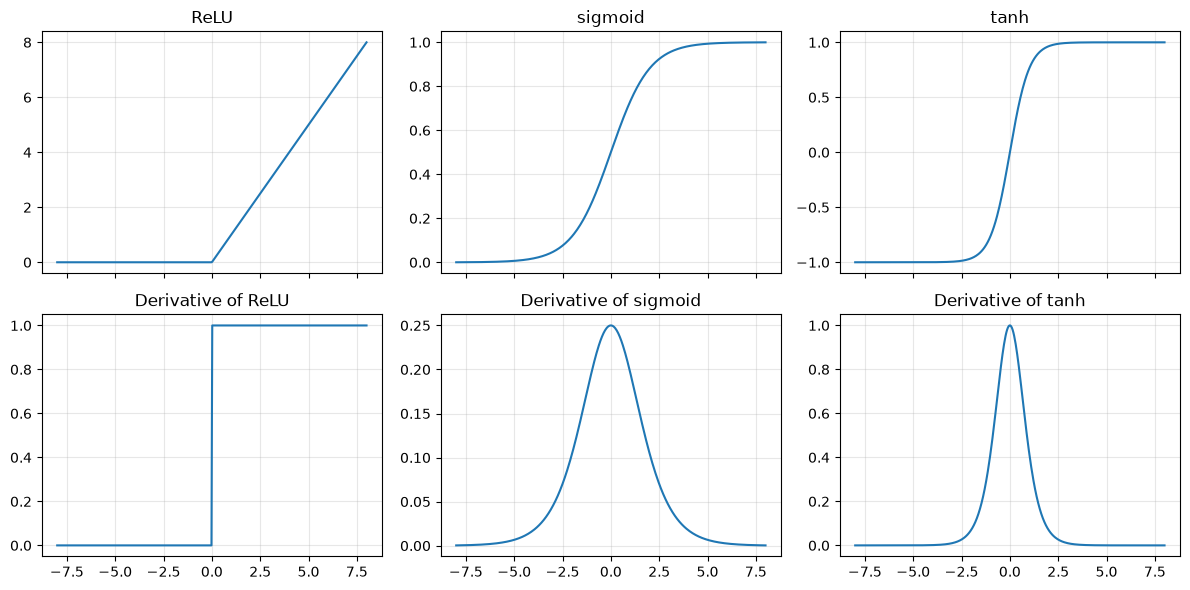

In [4]:
x = torch.linspace(-8, 8, 400, requires_grad=True)  # 激活函数采样点
activations = {  # 保存名称及其对应的激活函数输出
    'ReLU': torch.relu(x),  # 计算 ReLU 在各采样点的函数值
    'sigmoid': torch.sigmoid(x),  # 计算 sigmoid 在各采样点的函数值
    'tanh': torch.tanh(x),  # 计算 tanh 在各采样点的函数值
}  # 完成激活函数字典
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)  # 创建两行三列且共享横轴的画布
for column, (name, y) in enumerate(activations.items()):  # 逐列绘制一种激活函数及其导数
    gradient = torch.autograd.grad(y.sum(), x, retain_graph=True)[0]  # 对函数值之和求导以得到逐元素导数
    axes[0, column].plot(x.detach(), y.detach())  # 在第一行绘制激活函数曲线
    axes[0, column].set_title(name)  # 设置激活函数名称
    axes[1, column].plot(x.detach(), gradient.detach())  # 在第二行绘制导数曲线
    # 使用英文标题，避免 Colab 默认字体缺少中文字形而显示为方框。
    axes[1, column].set_title(f'Derivative of {name}')  # 设置对应导数图的标题
    for axis in axes[:, column]:  # 遍历当前列上下两个坐标轴
        axis.grid(alpha=0.3)  # 添加半透明网格以便读取数值
plt.tight_layout()  # 自动调整子图间距，防止文字重叠
figure_path = figure_dir / '4.1_activation_functions.png'  # 生成图片的完整保存路径
fig.savefig(figure_path, dpi=160, bbox_inches='tight')  # 以 160 DPI 保存并裁掉多余白边
print(f'图片已保存到：{figure_path}')  # 输出路径以便确认图片位置
plt.show()  # 在 Notebook 中显示完整图像

## 本节知识梳理

| 激活函数 | 输出范围 | 优点 | 主要问题 |
|---|---:|---|---|
| ReLU | $[0,\infty)$ | 快、正区间不饱和 | 负区间梯度为 0 |
| sigmoid | $(0,1)$ | 可解释为概率、适合门控 | 易饱和，输出非零中心 |
| tanh | $(-1,1)$ | 零中心 | 易饱和 |
| pReLU | $(-\infty,\infty)$ | 负区间仍可传梯度 | 多一个可学习参数 |

MLP 的核心数据流为：

$$\text{输入}\rightarrow\text{仿射变换}\rightarrow\text{非线性激活}\rightarrow\text{仿射输出}\rightarrow\text{损失}. $$

## 4.1.3 小结

- MLP 在输入与输出之间加入全连接隐藏层；
- 只有加入非线性激活函数，多层网络才不会退化为单个线性模型；
- ReLU 是最常用的隐藏层激活函数，sigmoid 和 tanh 在饱和区可能造成梯度消失；
- 隐藏层宽度、深度和激活函数都是影响模型容量的重要超参数。

## 4.1.4 练习

1. 计算 pReLU 激活函数的导数。
2. 证明仅使用 ReLU（或 pReLU）的多层感知机构造的是连续分段线性函数。
3. 证明 $\tanh(x)+1=2\operatorname{sigmoid}(2x)$。
4. 假设有一个一次只能处理一个样本、不能批量运算的非线性单元，将它应用于小批量数据会有什么问题？

## 4.1.5 练习题参考答案

### 练习 1

设 $\operatorname{pReLU}(x)=\max(0,x)+a\min(0,x)$，则

$$\frac{d}{dx}\operatorname{pReLU}(x)=\begin{cases}1,&x>0,\\a,&x<0.\end{cases}$$

$x=0$ 处左右导数通常不同，可选一个次梯度。若 $a$ 也是可学习参数，则 $\partial\operatorname{pReLU}/\partial a=\min(0,x)$。

### 练习 2

仿射变换连续且线性；ReLU 和 pReLU 都是连续分段线性函数。对连续分段线性函数做仿射组合，结果仍是连续分段线性函数；再次逐元素应用 ReLU/pReLU，只会依据各预激活值是否跨过 0 进一步划分区域。逐层归纳可知，有限层网络的输出在每个区域内是仿射函数，并在区域边界处连续。

### 练习 3

由指数定义直接化简：

$$\tanh(x)+1=\frac{e^x-e^{-x}}{e^x+e^{-x}}+1=\frac{2e^x}{e^x+e^{-x}}=\frac{2}{1+e^{-2x}}=2\operatorname{sigmoid}(2x).$$

### 练习 4

必须用 Python 循环逐样本调用，无法利用向量化、SIMD 和 GPU 并行，因而吞吐量很低；还可能破坏统一的批量维度，使自动微分、形状管理和部署更复杂。正确做法是让激活函数逐元素作用于整个张量，输入输出形状保持一致。